# Exploratory Data Analysis — `anti_derivative.npy`

This notebook explores the dataset used to train a Deep Operator Network (DeepONet) that learns the **1D anti-derivative operator**:

$$G: a(x) \mapsto u(x) = \int_0^x a(t)\, dt$$

Input functions `a` are sampled from a **Gaussian Random Field** with an exponential-quadratic (RBF) kernel.

---
### Dataset layout

| Split | Key prefix | Samples | Description |
|-------|-----------|---------|-------------|
| Train (data) | `a_train`, `x_train`, `u_train` | 10 000 | One random query point per sample |
| Train (residual) | `a_r_train`, `x_r_train`, `u_r_train` | 1 000 000 | Dense physics-informed residual points |
| Test | `a_test`, `x_test`, `u_test` | 10 000 | Held-out evaluation |

Each `a_*` array has shape `(N, 100)` — the input function at **100 sensor points** on [0, 1].  
Each `x_*` array has shape `(N, 1)` — the **query coordinate** where the anti-derivative is evaluated.  
Each `u_*` array has shape `(N, 1)` — the **ground-truth anti-derivative** value at that coordinate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

DATA_PATH = (
    'physicsnemo_sym_examples_supplemental_materials_v0.0.1'
    '/examples/anti_derivative/data/anti_derivative.npy'
)

raw = np.load(DATA_PATH, allow_pickle=True).item()

a_train   = raw['a_train']    # (10000, 100)
x_train   = raw['x_train']    # (10000, 1)
u_train   = raw['u_train']    # (10000, 1)

a_r_train = raw['a_r_train']  # (1000000, 100)
x_r_train = raw['x_r_train']  # (1000000, 1)
u_r_train = raw['u_r_train']  # (1000000, 1)

a_test    = raw['a_test']     # (10000, 100)
x_test    = raw['x_test']     # (10000, 1)
u_test    = raw['u_test']     # (10000, 1)

sensor_pts = np.linspace(0, 1, a_train.shape[1])  # 100 uniform sensor positions

print('Dataset loaded successfully.')
for name, arr in raw.items():
    print(f'  {name:<12}: shape={arr.shape}  dtype={arr.dtype}')

Dataset loaded successfully.
  a_train     : shape=(10000, 100)  dtype=float32
  x_train     : shape=(10000, 1)  dtype=float32
  u_train     : shape=(10000, 1)  dtype=float32
  a_r_train   : shape=(1000000, 100)  dtype=float32
  x_r_train   : shape=(1000000, 1)  dtype=float32
  u_r_train   : shape=(1000000, 1)  dtype=float32
  a_test      : shape=(10000, 100)  dtype=float32
  x_test      : shape=(10000, 1)  dtype=float32
  u_test      : shape=(10000, 1)  dtype=float32


## 1. Summary Statistics

In [2]:
arrays = [
    ('a_train',   a_train),
    ('x_train',   x_train),
    ('u_train',   u_train),
    ('a_r_train', a_r_train),
    ('x_r_train', x_r_train),
    ('u_r_train', u_r_train),
    ('a_test',    a_test),
    ('x_test',    x_test),
    ('u_test',    u_test),
]

header = f"{'array':<12} {'shape':<18} {'min':>8} {'max':>8} {'mean':>8} {'std':>8} {'p5':>8} {'median':>8} {'p95':>8}"
print(header)
print('-' * len(header))
for name, arr in arrays:
    f = arr.ravel()
    row = (
        f"{name:<12} {str(arr.shape):<18}"
        f" {f.min():>8.4f} {f.max():>8.4f} {f.mean():>8.4f} {f.std():>8.4f}"
        f" {np.percentile(f,5):>8.4f} {np.median(f):>8.4f} {np.percentile(f,95):>8.4f}"
    )
    print(row)

array        shape                   min      max     mean      std       p5   median      p95
----------------------------------------------------------------------------------------------
a_train      (10000, 100)        -4.4289   4.2628   0.0053   0.9961  -1.6299   0.0083   1.6378
x_train      (10000, 1)           0.0004   1.0000   0.5009   0.2900   0.0533   0.5001   0.9484
u_train      (10000, 1)          -2.2439   2.3283   0.0062   0.4254  -0.7038   0.0022   0.7291
a_r_train    (1000000, 100)      -4.4289   4.2628   0.0053   0.9961  -1.6299   0.0083   1.6378
x_r_train    (1000000, 1)         0.0000   1.0000   0.5000   0.2916   0.0500   0.5000   0.9501
u_r_train    (1000000, 1)        -4.4289   4.2628   0.0053   0.9961  -1.6299   0.0083   1.6378
a_test       (10000, 100)        -3.7735   3.4265  -0.0297   1.0675  -1.7695  -0.0273   1.6509
x_test       (10000, 1)           0.0000   1.0000   0.5000   0.2916   0.0500   0.5000   0.9500
u_test       (10000, 1)          -2.2945   1.9077 

## 2. Query-Coordinate Distributions

Where on [0, 1] are the anti-derivative values queried for each split?

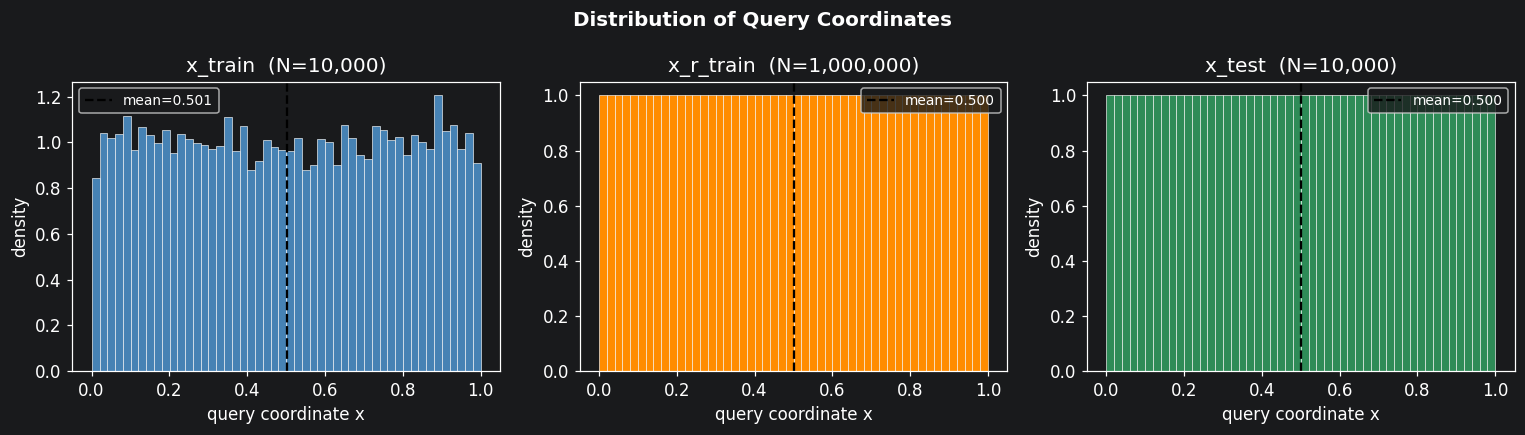

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

splits = [
    (x_train,   'x_train',   'steelblue'),
    (x_r_train, 'x_r_train', 'darkorange'),
    (x_test,    'x_test',    'seagreen'),
]

for ax, (x, label, color) in zip(axes, splits):
    ax.hist(x.ravel(), bins=50, color=color, edgecolor='white', linewidth=0.4, density=True)
    ax.axvline(x.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'mean={x.mean():.3f}')
    ax.set_title(f'{label}  (N={len(x):,})')
    ax.set_xlabel('query coordinate x')
    ax.set_ylabel('density')
    ax.legend(fontsize=9)

fig.suptitle('Distribution of Query Coordinates', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Input-Function Samples (GRF realizations)

Each row of `a_train` is one Gaussian Random Field realization evaluated at 100 sensor positions.

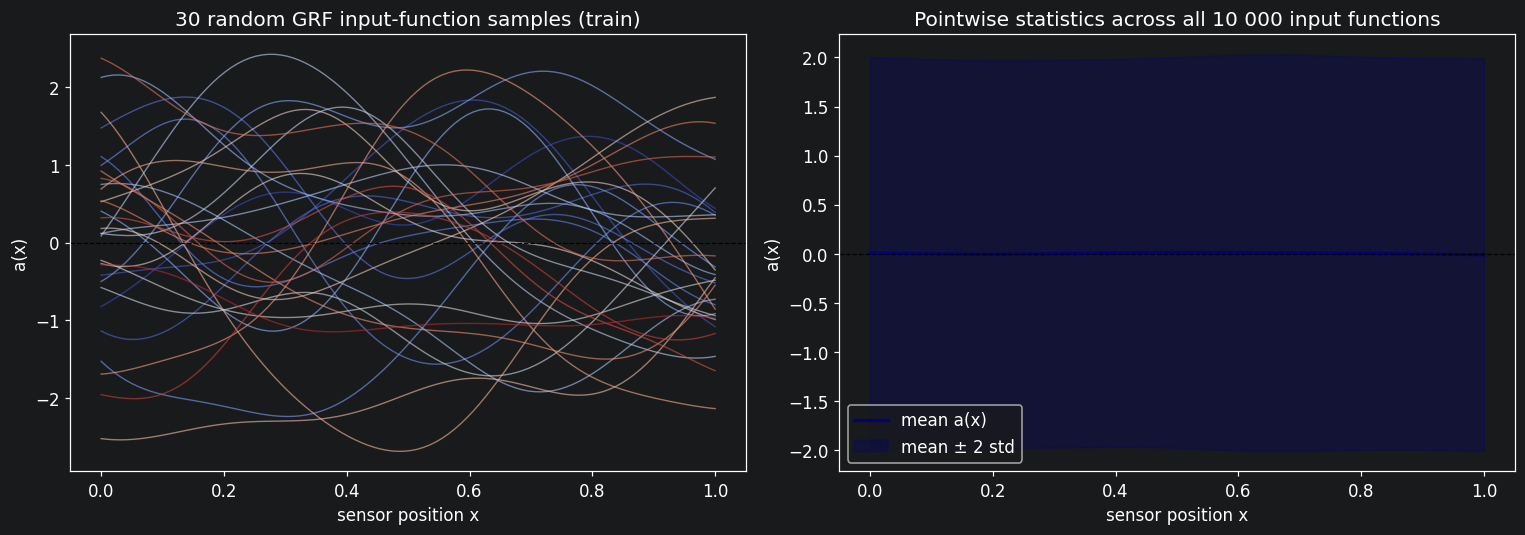

In [4]:
N_SHOW = 30
rng = np.random.default_rng(42)
idx = rng.choice(len(a_train), N_SHOW, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cmap = plt.cm.coolwarm
for i, si in enumerate(idx):
    ax.plot(sensor_pts, a_train[si], color=cmap(i / N_SHOW), alpha=0.6, linewidth=0.9)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('sensor position x')
ax.set_ylabel('a(x)')
ax.set_title(f'{N_SHOW} random GRF input-function samples (train)')

ax = axes[1]
mean_a = a_train.mean(axis=0)
std_a  = a_train.std(axis=0)
ax.plot(sensor_pts, mean_a, color='navy', linewidth=2, label='mean a(x)')
ax.fill_between(sensor_pts, mean_a - 2*std_a, mean_a + 2*std_a,
                alpha=0.25, color='navy', label='mean ± 2 std')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('sensor position x')
ax.set_ylabel('a(x)')
ax.set_title('Pointwise statistics across all 10 000 input functions')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Paired Input / Anti-Derivative Curves

For a handful of training samples we numerically integrate `a(x)` across all sensors to reconstruct the full anti-derivative curve `u(x) = ∫₀ˣ a(t) dt`, then verify the stored dataset query point falls on it.

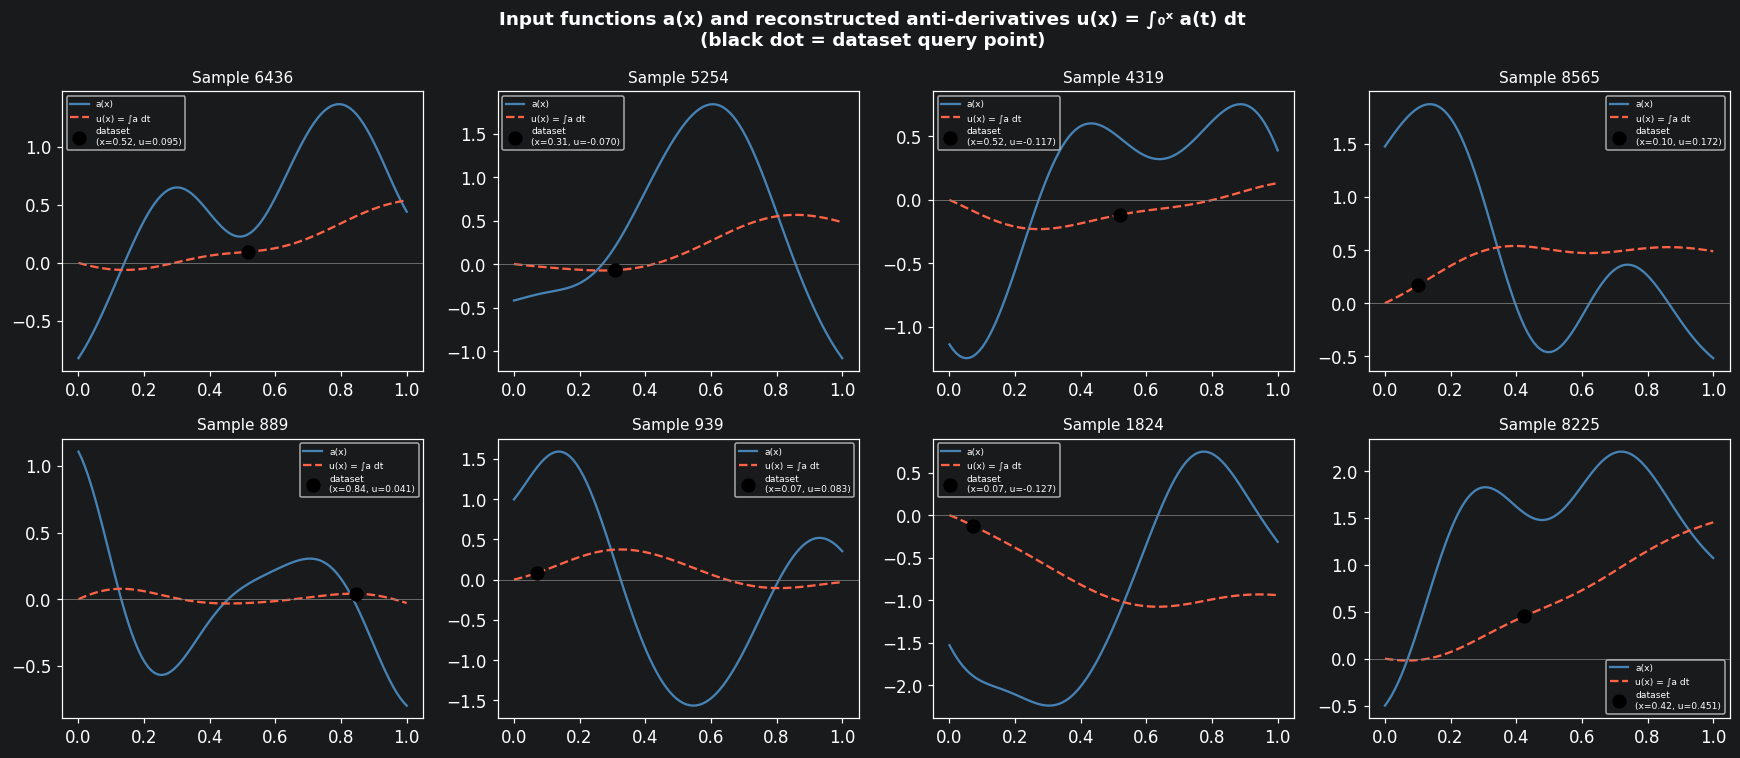

In [14]:
N_SHOW = 8
idx8 = idx[:N_SHOW]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

for plot_i, si in enumerate(idx8):
    ax = axes[plot_i]
    a_i = a_train[si]   # (100,)

    # cumulative trapezoid integration
    u_curve = np.zeros(100)
    for j in range(1, 100):
        u_curve[j] = np.trapezoid(a_i[:j+1], sensor_pts[:j+1])

    ax.plot(sensor_pts, a_i,      color='steelblue', linewidth=1.5, label='a(x)')
    ax.plot(sensor_pts, u_curve,  color='tomato',    linewidth=1.5,
            linestyle='--', label='u(x) = ∫a dt')

    qx = float(x_train[si])
    qu = float(u_train[si])
    ax.scatter([qx], [qu], color='black', zorder=5, s=70,
               label=f'dataset\n(x={qx:.2f}, u={qu:.3f})')

    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_title(f'Sample {si}', fontsize=10)
    ax.legend(fontsize=6)

fig.suptitle(
    'Input functions a(x) and reconstructed anti-derivatives u(x) = ∫₀ˣ a(t) dt\n'
    '(black dot = dataset query point)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 5. Marginal Distributions of `a` and `u`

The GRF is a zero-mean Gaussian process, so pointwise values of `a` should be near-Gaussian. Integration preserves Gaussianity but reduces variance (smoothing effect).

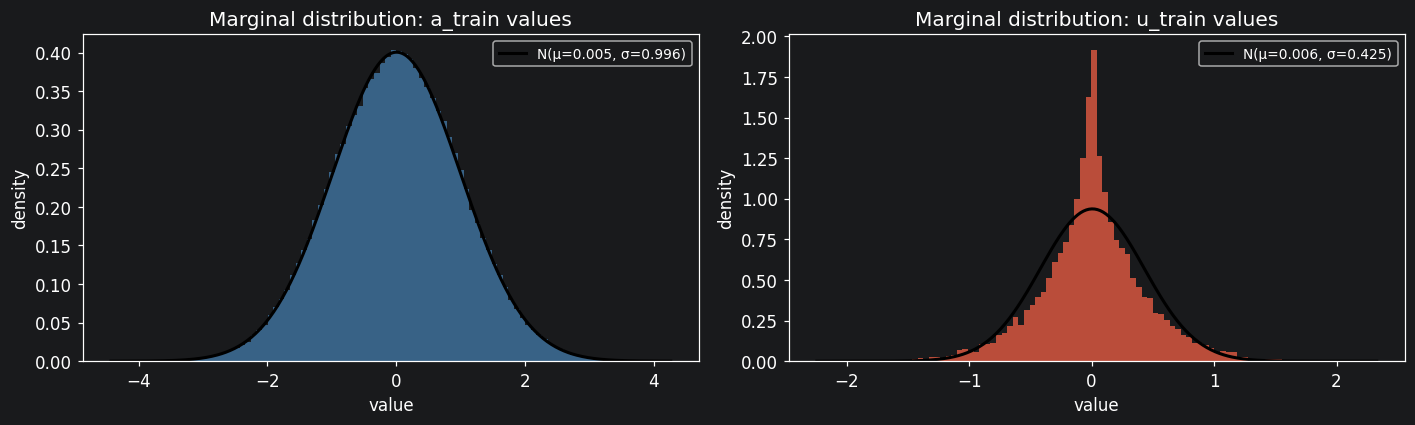

D'Agostino-Pearson normality test p-value
  a_train: 0.1654  (Gaussian at alpha=0.05)
  u_train: 0.0000  (non-Gaussian at alpha=0.05)

Std ratio sigma(a)/sigma(u) = 2.34  (integration reduces spread)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (arr, label, color) in zip(axes, [
        (a_train, 'a_train values', 'steelblue'),
        (u_train, 'u_train values', 'tomato'),
    ]):
    flat = arr.ravel()
    ax.hist(flat, bins=100, density=True, color=color, alpha=0.7, edgecolor='none')
    xs = np.linspace(flat.min(), flat.max(), 400)
    ax.plot(xs, stats.norm.pdf(xs, flat.mean(), flat.std()),
            'k-', linewidth=2, label=f'N(μ={flat.mean():.3f}, σ={flat.std():.3f})')
    ax.set_title(f'Marginal distribution: {label}')
    ax.set_xlabel('value')
    ax.set_ylabel('density')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

fa = a_train.ravel()
fu = u_train.ravel()
_, p_a = stats.normaltest(rng.choice(fa, 5000, replace=False))
_, p_u = stats.normaltest(rng.choice(fu, 5000, replace=False))
print("D'Agostino-Pearson normality test p-value")
print(f'  a_train: {p_a:.4f}  ({"Gaussian" if p_a > 0.05 else "non-Gaussian"} at alpha=0.05)')
print(f'  u_train: {p_u:.4f}  ({"Gaussian" if p_u > 0.05 else "non-Gaussian"} at alpha=0.05)')
print(f'\nStd ratio sigma(a)/sigma(u) = {fa.std()/fu.std():.2f}  (integration reduces spread)')

## 6. Sensor-Wise Statistics

How does the distribution of `a` values vary across the 100 sensor positions? A stationary GRF should show uniform mean and variance.

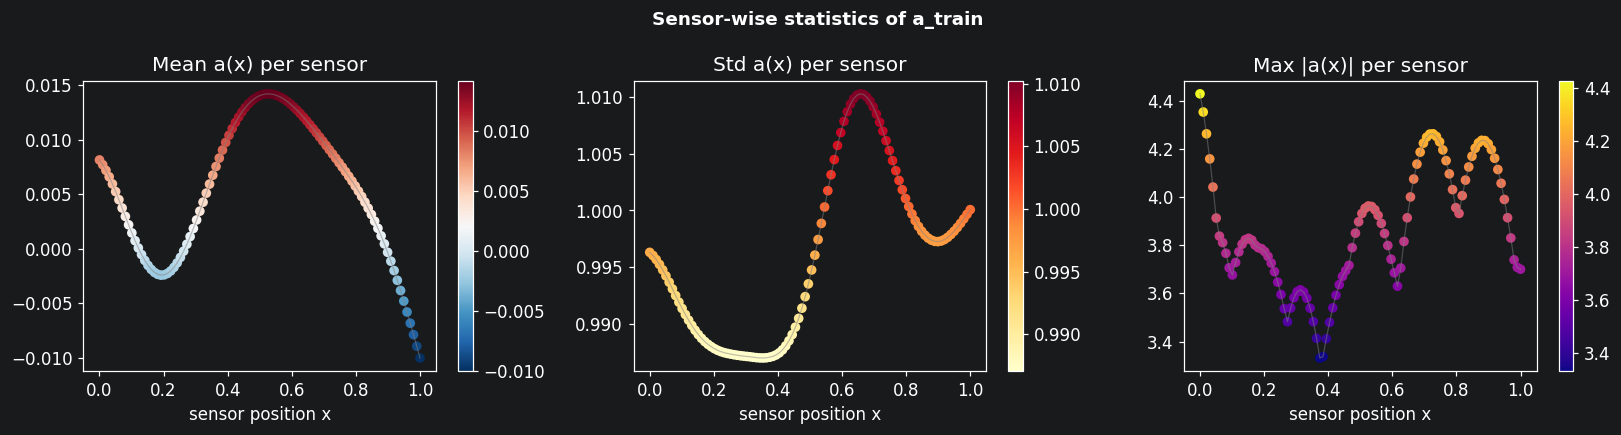

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sensor_mean = a_train.mean(axis=0)
sensor_std  = a_train.std(axis=0)
sensor_absmax = np.abs(a_train).max(axis=0)

for ax, (values, title, cmap) in zip(axes, [
        (sensor_mean,   'Mean a(x) per sensor',    'RdBu_r'),
        (sensor_std,    'Std a(x) per sensor',     'YlOrRd'),
        (sensor_absmax, 'Max |a(x)| per sensor',   'plasma'),
    ]):
    sc = ax.scatter(sensor_pts, values, c=values, cmap=cmap, s=40, edgecolors='none')
    ax.plot(sensor_pts, values, color='gray', linewidth=0.8, alpha=0.5)
    plt.colorbar(sc, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('sensor position x')

fig.suptitle('Sensor-wise statistics of a_train', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Spatial Correlation Structure

The GRF's RBF kernel induces spatial correlations between nearby sensor values.

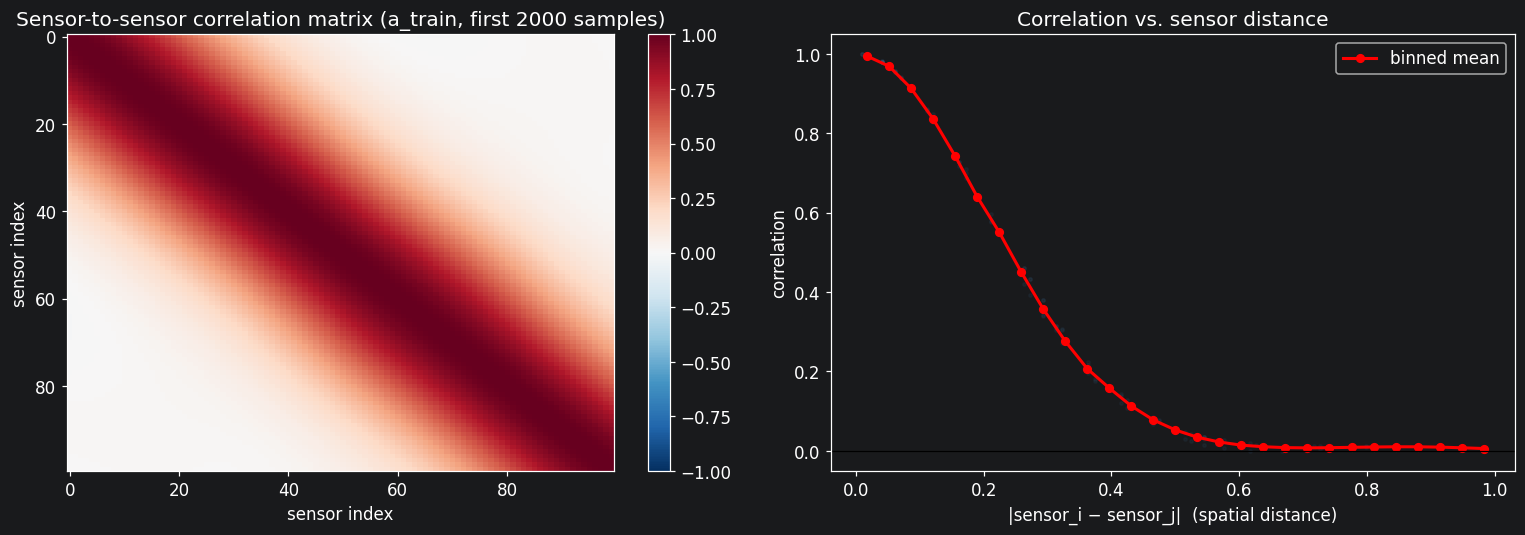

In [17]:
corr = np.corrcoef(a_train[:2000].T)  # (100, 100) correlation matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Sensor-to-sensor correlation matrix (a_train, first 2000 samples)')
axes[0].set_xlabel('sensor index')
axes[0].set_ylabel('sensor index')

# collapse to correlation vs distance
n = corr.shape[0]
dists, corrs = [], []
for i in range(n):
    for j in range(i + 1, n):
        dists.append(abs(sensor_pts[i] - sensor_pts[j]))
        corrs.append(corr[i, j])
dists = np.array(dists)
corrs = np.array(corrs)

bins = np.linspace(0, 1, 30)
bin_means = [
    corrs[(dists >= bins[k]) & (dists < bins[k+1])].mean()
    for k in range(len(bins) - 1)
]
bin_centers = 0.5 * (bins[:-1] + bins[1:])

axes[1].scatter(dists[::50], corrs[::50], alpha=0.07, s=5, color='steelblue')
axes[1].plot(bin_centers, bin_means, 'r-o', linewidth=2, markersize=5, label='binned mean')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('|sensor_i − sensor_j|  (spatial distance)')
axes[1].set_ylabel('correlation')
axes[1].set_title('Correlation vs. sensor distance')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Anti-Derivative Value vs. Query Coordinate

Because `u(x) = ∫₀ˣ a(t) dt`, samples queried at larger `x` integrate over a longer interval — we expect the variance of `u` to grow with `x`.

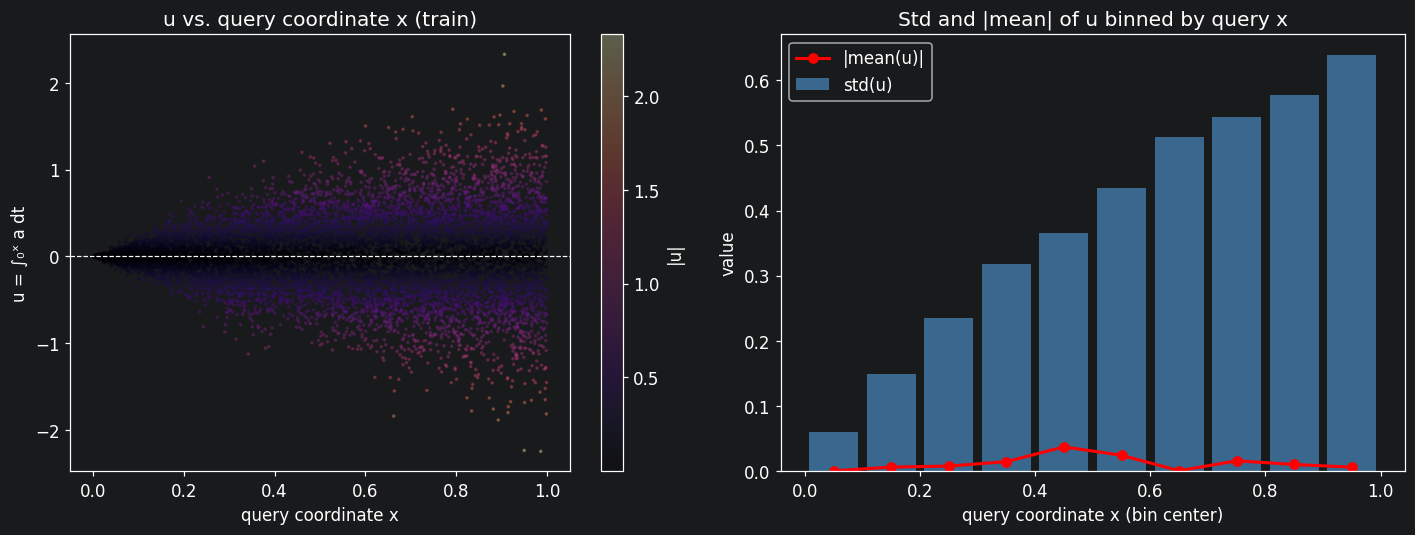

Std of u per x-bin (x≈0 → x≈1): ['0.060', '0.149', '0.235', '0.318', '0.366', '0.435', '0.512', '0.543', '0.578', '0.638']


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# scatter: x vs u
ax = axes[0]
sc = ax.scatter(x_train.ravel(), u_train.ravel(),
                c=np.abs(u_train.ravel()), cmap='magma', s=2, alpha=0.3)
plt.colorbar(sc, ax=ax, label='|u|')
ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
ax.set_xlabel('query coordinate x')
ax.set_ylabel('u = ∫₀ˣ a dt')
ax.set_title('u vs. query coordinate x (train)')

# std of u binned by x
ax = axes[1]
x_flat = x_train.ravel()
u_flat = u_train.ravel()
bin_edges = np.linspace(0, 1, 11)
groups = [
    u_flat[(x_flat >= bin_edges[k]) & (x_flat < bin_edges[k+1])]
    for k in range(10)
]
centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
stds    = [g.std() if len(g) > 0 else 0 for g in groups]
means   = [g.mean() if len(g) > 0 else 0 for g in groups]

ax.bar(centers, stds, width=0.085, color='steelblue', alpha=0.75, label='std(u)')
ax.plot(centers, np.abs(means), 'ro-', linewidth=2, markersize=6, label='|mean(u)|')
ax.set_xlabel('query coordinate x (bin center)')
ax.set_ylabel('value')
ax.set_title('Std and |mean| of u binned by query x')
ax.legend()

plt.tight_layout()
plt.show()

print('Std of u per x-bin (x≈0 → x≈1):', [f'{s:.3f}' for s in stds])

## 9. Train / Test Distribution Comparison

Are the training and test splits drawn from the same distribution? A two-sample KS test checks this formally.

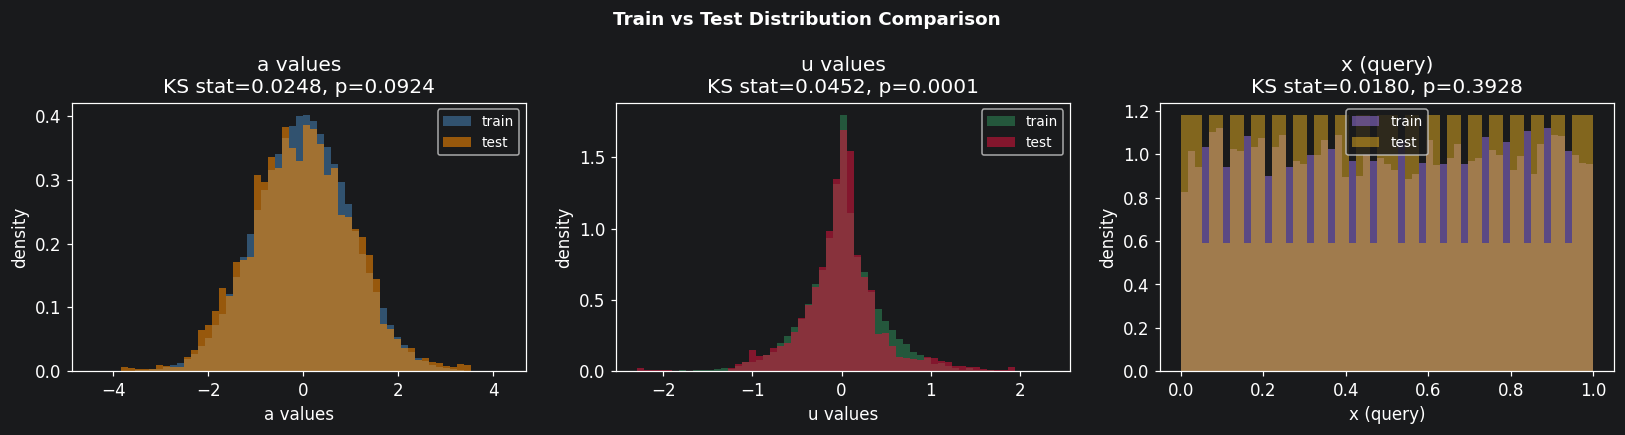

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

comparisons = [
    (a_train.ravel(), a_test.ravel(), 'a values',  'steelblue',    'darkorange'),
    (u_train.ravel(), u_test.ravel(), 'u values',  'seagreen',     'crimson'),
    (x_train.ravel(), x_test.ravel(), 'x (query)', 'mediumpurple', 'goldenrod'),
]

for ax, (tr, te, label, c1, c2) in zip(axes, comparisons):
    lo = min(tr.min(), te.min())
    hi = max(tr.max(), te.max())
    bins = np.linspace(lo, hi, 60)
    ax.hist(tr, bins=bins, density=True, alpha=0.55, color=c1, label='train')
    ax.hist(te, bins=bins, density=True, alpha=0.55, color=c2, label='test')

    ks_stat, ks_p = stats.ks_2samp(
        rng.choice(tr, 5000, replace=False),
        rng.choice(te, 5000, replace=False),
    )
    ax.set_title(f'{label}\nKS stat={ks_stat:.4f}, p={ks_p:.4f}')
    ax.set_xlabel(label)
    ax.set_ylabel('density')
    ax.legend(fontsize=9)

fig.suptitle('Train vs Test Distribution Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Residual Training Split Overview

The residual split (1 M samples) provides dense physics-informed supervision. We check that its distribution matches the main training set.

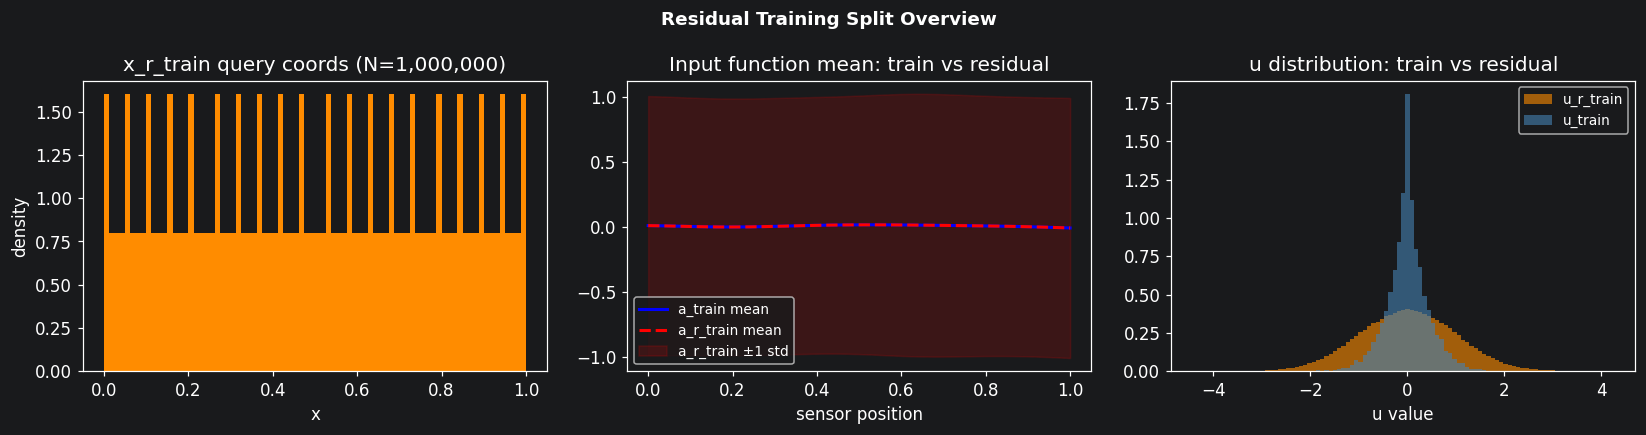

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# x_r_train coverage
axes[0].hist(x_r_train.ravel(), bins=80, density=True,
             color='darkorange', edgecolor='none')
axes[0].set_title(f'x_r_train query coords (N={len(x_r_train):,})')
axes[0].set_xlabel('x')
axes[0].set_ylabel('density')

# input function mean: residual vs train
axes[1].plot(sensor_pts, a_train.mean(axis=0), 'b-', linewidth=2, label='a_train mean')
axes[1].plot(sensor_pts, a_r_train.mean(axis=0), 'r--', linewidth=2, label='a_r_train mean')
std_ar = a_r_train.std(axis=0)
mean_ar = a_r_train.mean(axis=0)
axes[1].fill_between(sensor_pts, mean_ar - std_ar, mean_ar + std_ar,
                     alpha=0.15, color='red', label='a_r_train ±1 std')
axes[1].set_title('Input function mean: train vs residual')
axes[1].set_xlabel('sensor position')
axes[1].legend(fontsize=9)

# u distribution: residual vs train
lo = min(u_r_train.min(), u_train.min())
hi = max(u_r_train.max(), u_train.max())
bins = np.linspace(lo, hi, 100)
axes[2].hist(u_r_train.ravel(), bins=bins, density=True,
             color='darkorange', alpha=0.6, label='u_r_train')
axes[2].hist(u_train.ravel(), bins=bins, density=True,
             color='steelblue', alpha=0.6, label='u_train')
axes[2].set_title('u distribution: train vs residual')
axes[2].set_xlabel('u value')
axes[2].legend(fontsize=9)

fig.suptitle('Residual Training Split Overview', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. PCA of Input Functions (numpy SVD)

We reduce the 100-dimensional input-function space to 2D to visualize the spread of samples and how the anti-derivative value `u` relates to principal component directions.

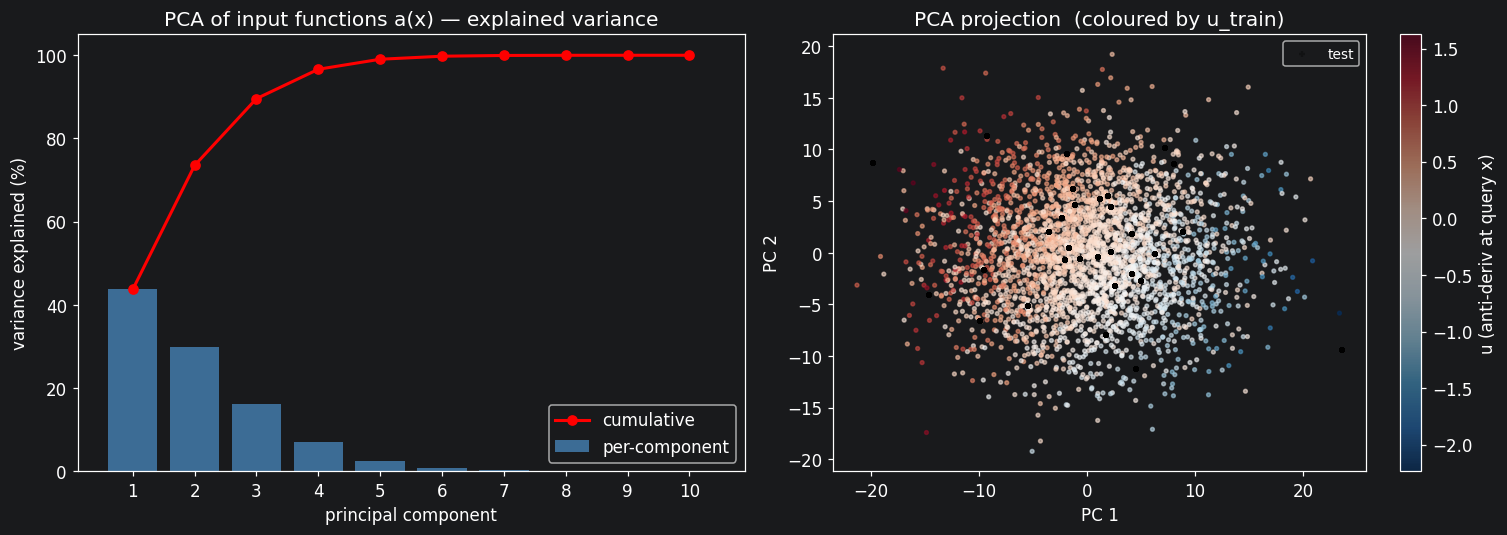

Variance explained by first 2 PCs : 73.5%
Variance explained by first 10 PCs: 100.0%


In [21]:
N_sub = 3000
a_sub_tr = a_train[:N_sub]
a_sub_te = a_test[:N_sub]

# center on training mean
a_all_mean = a_train.mean(axis=0)
a_c = a_train - a_all_mean          # (10000, 100)

# thin SVD: U (10000×k), S (k,), Vt (k×100)
_, S, Vt = np.linalg.svd(a_c / np.sqrt(len(a_train) - 1), full_matrices=False)
explained = (S**2) / (S**2).sum()

proj_tr = (a_sub_tr - a_all_mean) @ Vt[:10].T   # (N_sub, 10)
proj_te = (a_sub_te - a_all_mean) @ Vt[:10].T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cumvar = np.cumsum(explained[:10])
ax.bar(range(1, 11), explained[:10] * 100, color='steelblue', alpha=0.8, label='per-component')
ax.plot(range(1, 11), cumvar * 100, 'ro-', linewidth=2, markersize=6, label='cumulative')
ax.set_xlabel('principal component')
ax.set_ylabel('variance explained (%)')
ax.set_title('PCA of input functions a(x) — explained variance')
ax.set_xticks(range(1, 11))
ax.legend()

ax = axes[1]
sc = ax.scatter(proj_tr[:, 0], proj_tr[:, 1],
                c=u_train[:N_sub].ravel(), cmap='RdBu_r', s=6, alpha=0.6)
ax.scatter(proj_te[:, 0], proj_te[:, 1],
           marker='+', s=12, color='black', alpha=0.3, label='test')
plt.colorbar(sc, ax=ax, label='u (anti-deriv at query x)')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('PCA projection  (coloured by u_train)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Variance explained by first 2 PCs : {cumvar[1]*100:.1f}%')
print(f'Variance explained by first 10 PCs: {cumvar[9]*100:.1f}%')

p## 12. Key Findings Summary